<p align="left">
  <img src="../../images/pyspatialstats_logo.png" alt="PySpatialStats logo" width="140"/>
</p>


# PySpatialStats Getting Started

A short, runnable tour of the **0.3** package: spatial weights, autocorrelation, regression, hot spots, disease mapping, interpolation, sampling, point patterns, and a first geographically weighted regression.

**Audience:** GIS analysts, spatial statisticians, and anyone new to the `spatialstats` API.

**Prerequisites:** Python 3.9+, and a basic familiarity with NumPy, pandas, and regression.

Each section fits one model or test on the Northeast county diabetes layer, then points to the chapter notebook that goes further. Deeper GW variants (MGWR, GW machine learning, GTWR, GNNWR) live in the Chapter 6 notebooks.

## Data used here

| Dataset | File | Used for |
|---|---|---|
| Northeast diabetes counties | `data/diabetes_northeast.shp` (EPSG:5070) | Weights, ESDA, regression, hot spots, rates, GWR |
| County centroids (`x`, `y`) | same shapefile | Interpolation and sampling |
| Synthetic CSR points | `spatialstats.datasets.load_points_csr` | Point patterns |

The matching CSV (`data/diabetes_northeast.csv`) is the same table with longer column names. This notebook reads the **shapefile**, because contiguity weights need the polygons and a projected CRS.

| Shapefile field | CSV field | Meaning |
|---|---|---|
| `Dia_pct` | `Diabetes_per` | Diabetes prevalence (%) |
| `Dia_count` | `Diabetes_count` | Diabetes counts |
| `PhysInact` | `Physical_Inactivity` | Physical inactivity |
| `FoodEnvIdx` | `Food_Env_Index` | Food-environment index |
| `UrbRural` | `Urban_Rural` | Urban / rural |
| `x`, `y` | `X`, `Y` | Projected coordinates (metres) |

Run from the repository root, or from this folder: the data path is resolved by walking up from the working directory.


***

## Table of Contents

1. [What is PySpatialStats?](#1.-What-is-PySpatialStats?)
2. [Installation and environment check](#2.-Installation-and-environment-check)
3. [Load the Northeast counties](#3.-Load-the-Northeast-counties)
4. [Spatial weights and autocorrelation](#4.-Spatial-weights-and-autocorrelation)
5. [Spatial regression](#5.-Spatial-regression)
6. [Hot spots](#6.-Hot-spots)
7. [Disease mapping](#7.-Disease-mapping)
8. [Interpolation](#8.-Interpolation)
9. [Sampling](#9.-Sampling)
10. [Point patterns](#10.-Point-patterns)
11. [Geographically weighted regression](#11.-Geographically-weighted-regression)
12. [Where to go next](#12.-Where-to-go-next)
13. [Choosing a method](#13.-Choosing-a-method)
14. [Troubleshooting](#14.-Troubleshooting)
15. [Further reading](#15.-Further-reading)


## 1. What is PySpatialStats?

`spatialstats` is a Python package for spatial statistics and geographically weighted modelling. Version **0.3.0** is organised as one module per question.

| Module | Question it answers | Start here |
|---|---|---|
| `core` | Containers, CRS checks, distances | [Chapter 0.2](ch00_2_spatial_data_types_and_containers.ipynb) |
| `weights` | Who is a neighbour? | [Chapter 2.2](ch02_2_spatial_weights.ipynb) |
| `esda` | Is the map autocorrelated? | [Chapter 2.4](ch02_4_global_autocorrelation.ipynb) |
| `viz` | Choropleth, Moran scatter, LISA map | [Chapter 0.4](ch00_4_datasets_maps_and_workflow.ipynb) |
| `regression` | Does the outcome need a spatial model? | [Chapter 3.2](ch03_2_ols_baseline_diagnostics.ipynb) |
| `cluster` | Where are hot spots, scans, or regions? | [Chapter 4.2](ch04_2_hotspot_detection.ipynb) |
| `bayes` | How should unstable small-area rates be smoothed? | [Chapter 5.5](ch05_5_empirical_bayes.ipynb) |
| `interpolate` | What is the surface between the points? | [Chapter 7.3](ch07_3_deterministic_interpolation.ipynb) |
| `sampling` | Where should the next sample go? | [Chapter 8.2](ch08_2_sampling_designs.ipynb) |
| `pointpattern` | Are events clustered in a window? | [Chapter 1.1](ch01_1_point_pattern_fundamentals.ipynb) |
| `gwmodel` | Do relationships vary across space? | [Chapter 6.1](ch06_1_introduction_motivation.ipynb) |
| `datasets` | Teaching loaders (`load_lattice`, `load_georgia`, …) | [Chapter 0.4](ch00_4_datasets_maps_and_workflow.ipynb) |
| `spacetime` | Planned. Tutorials sketch the workflow. | [Chapter 9.1](ch09_1_concepts_data.ipynb) |

The public names used below (`Queen`, `Moran`, `GWR`, …) are exported from `spatialstats` itself.


## 2. Installation and environment check

```bash
pip install git+https://github.com/zia207/PySpatialStats.git
```

Optional extras, from the same repository:

```bash
pip install "pyspatialstats[viz] @ git+https://github.com/zia207/PySpatialStats.git"       # matplotlib / folium
pip install "pyspatialstats[deep] @ git+https://github.com/zia207/PySpatialStats.git"      # PyTorch (GNNWR, GTNNWR)
pip install "pyspatialstats[boosting] @ git+https://github.com/zia207/PySpatialStats.git"  # XGBoost, LightGBM
pip install "pyspatialstats[libpysal] @ git+https://github.com/zia207/PySpatialStats.git"  # libpysal weight converters
pip install "pyspatialstats[bayes] @ git+https://github.com/zia207/PySpatialStats.git"     # PyMC / ArviZ (optional BYM backend)
pip install "pyspatialstats[gam] @ git+https://github.com/zia207/PySpatialStats.git"       # pyGAM (regression kriging)
pip install "pyspatialstats[all] @ git+https://github.com/zia207/PySpatialStats.git"       # everything
```

From a local checkout: `pip install -e ".[all]"`.


In [1]:
import spatialstats

print("spatialstats version:", spatialstats.__version__)

from spatialstats import Queen, Moran, GWR
print("PySpatialStats", spatialstats.__version__, "ready.")


spatialstats version: 0.3.0
PySpatialStats 0.3.0 ready.


## 3. Load the Northeast counties

217 counties in a projected CRS (EPSG:5070, metres). Later sections reuse `gdf`, `features`, `target`, and `coords`.


In [2]:
%matplotlib inline
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

_ROOT = Path.cwd()
for _cand in [Path.cwd(), *Path.cwd().parents]:
    if (_cand / "data" / "diabetes_northeast.shp").exists():
        _ROOT = _cand
        break
DATA = _ROOT / "data"

gdf = gpd.read_file(DATA / "diabetes_northeast.shp")
features = ["Obesity", "PhysInact", "PCP_rate", "FoodEnvIdx", "SVI"]
target = "Dia_pct"
coords = gdf[["x", "y"]].to_numpy(dtype=float)

print(f"n={len(gdf)}  crs={gdf.crs}")
print("Target:", target, "   features:", features)
gdf[["COUNTY", "STATE", target] + features].head()


n=217  crs=EPSG:5070
Target: Dia_pct    features: ['Obesity', 'PhysInact', 'PCP_rate', 'FoodEnvIdx', 'SVI']


,COUNTY,STATE,Dia_pct,Obesity,PhysInact,PCP_rate,FoodEnvIdx,SVI
0,Fairfield County,Connecticut,6.42,21.48,17.34,93.8,8.5,0.6184
1,Hartford County,Connecticut,8.58,27.66,20.20,95.2,8.0,0.5955
2,Litchfield County,Connecticut,6.38,26.56,17.50,59.4,8.6,0.1512
3,Middlesex County,Connecticut,6.32,26.42,17.06,73.8,8.4,0.1843
4,New Haven County,Connecticut,8.84,29.64,20.78,88.2,7.9,0.6512


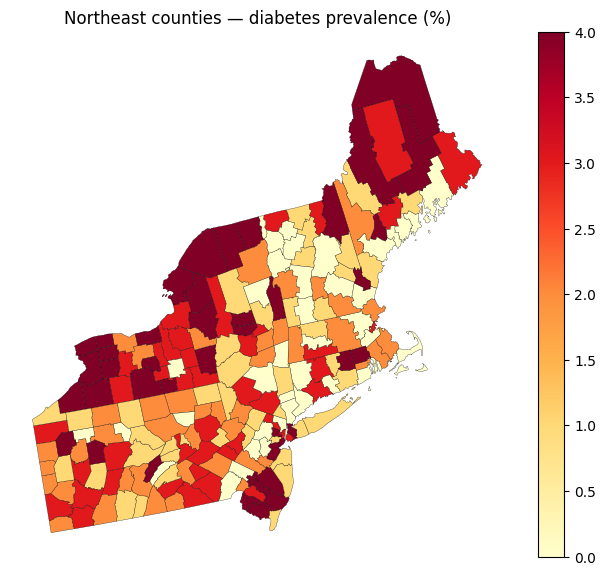

In [3]:
from spatialstats.viz import choropleth

ax = choropleth(gdf, target, scheme="quantiles", k=5, cmap="YlOrRd")
ax.set_title("Northeast counties — diabetes prevalence (%)")
plt.tight_layout()
plt.show()


## 4. Spatial weights and autocorrelation

`Queen` builds a row-standardised contiguity graph (shared edge or vertex). `Moran` tests whether neighbouring counties have similar prevalence. A positive Moran's I with a small permutation p-value means the map is clustered.

Chapter 2 covers Rook, k-nearest neighbours, distance bands, and local indicators (LISA).


Counties: 217    mean neighbours: 5.19
Moran's I
  I                    0.239826
  expected_I           -0.00462963
  var_I                0.0018983
  z_score              5.61069
  p_value              0.005
  p_norm               2.01516e-08
  p_sim                0.005
  permutations         199
  n                    217


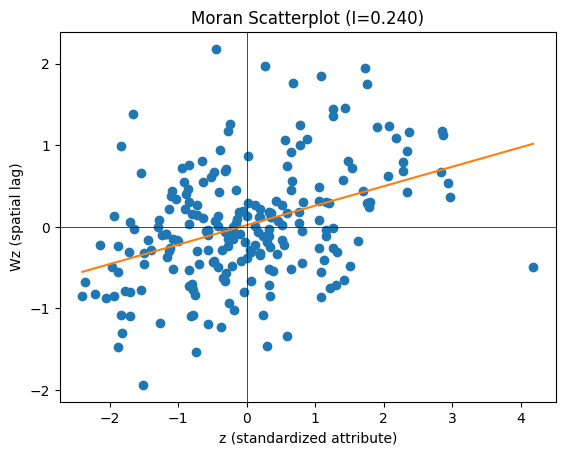

In [4]:
w = Queen(gdf)
mi = Moran(gdf[target], w, permutations=199, seed=1)
print(f"Counties: {w.n}    mean neighbours: {np.mean([len(v) for v in w.neighbors.values()]):.2f}")
print(mi.summary())

mi.plot()
plt.show()


## 5. Spatial regression

Fit OLS of prevalence on the five covariates, then let the Lagrange Multiplier tests say whether a spatial lag or a spatial error term is warranted. `compare_models` puts OLS, the spatial lag model, and the spatial error model in one table.

`X` is passed **without** an intercept; `OLS` adds one.


In [5]:
from spatialstats.regression import OLS, SpatialLag, SpatialError, compare_models

X = gdf[features]
y = gdf[target]

ols = OLS(y, X, w=w)
print(ols.lm_tests().recommendation())

slm = SpatialLag(y, X, w)
sem = SpatialError(y, X, w)
compare_models({"OLS": ols, "SLM": slm, "SEM": sem})[["aic", "resid_moran_I"]]


Spatial error model


,aic,resid_moran_I
model,,
OLS,419.701165,0.139427
SLM,420.251574,0.106044
SEM,412.249193,-0.002942


## 6. Hot spots

`getis_ord_gi` flags counties whose neighbourhood prevalence is higher (hot) or lower (cold) than chance, with FDR control across the 217 local tests. This is a cluster of **values**, not a cluster of events.

Chapter 4 adds LISA cluster types, the Kulldorff scan statistic, DBSCAN, and SKATER regions.


In [6]:
from spatialstats.cluster import getis_ord_gi

hot = getis_ord_gi(gdf[target], w, permutations=99, seed=1)
print(f"Hot spots: {int(hot.hot.sum())}    cold spots: {int(hot.cold.sum())}")
hot.to_frame()["label"].value_counts()


Hot spots: 7    cold spots: 3


label
Not significant    207
Hot spot 90%         5
Cold spot 90%        3
Hot spot 95%         2
Name: count, dtype: int64

## 7. Disease mapping

Prevalence (`Dia_pct`) is already a rate. Counts (`Dia_count`) divided by population are not: small counties have noisy ratios. Empirical Bayes shrinks each county's relative risk toward the regional mean, and counties with a small expected count are pulled hardest.

On this layer the expected counts are large, so the weight on the data stays near 1 and the smoothed risks barely move. The same call on a rare outcome, or on much smaller populations, shrinks much harder (Chapter 5).

`BYM` (Chapter 5.6) is the full Bayesian smoother. The built-in sampler needs no extra install; `backend="pymc"` needs the `bayes` extra.


In [7]:
from spatialstats.bayes import expected_counts, smr, eb_gamma_poisson

O = gdf["Dia_count"].to_numpy()
E = expected_counts(gdf["POP_Total"], observed=O)
raw = smr(O, E)
eb = eb_gamma_poisson(O, E)

print(f"Median SMR: {np.median(raw):.3f}")
print(f"Median EB relative risk: {np.median(eb.estimate):.3f}")
print(f"Mean weight on the data: {eb.shrinkage.mean():.3f}  (1 = no shrinkage)")
print(eb.summary())


Median SMR: 1.054
Median EB relative risk: 1.054
Mean weight on the data: 0.989  (1 = no shrinkage)
EB gamma-Poisson
  shape                47.4826
  rate                 45.1416
  prior_var            0.0233013
  method               mle
  prior_mean           1.05186


## 8. Interpolation

Treat county centroids as sample locations and predict prevalence at unsampled coordinates. Coordinates are already in metres (EPSG:5070), which distance-based interpolators require. `compare_methods` scores inverse-distance weighting against nearest neighbour with the same 5-fold split.

Chapter 7 covers variograms, kriging, and areal interpolation.


In [8]:
from spatialstats.interpolate import IDW, NearestNeighbor, compare_methods

xy = np.column_stack([gdf.geometry.centroid.x, gdf.geometry.centroid.y])
z = gdf[target].to_numpy(dtype=float)

idw = IDW(power=2, k=8).fit(xy, z)
# Exact at a sample location; a real prediction sits between counties.
mid = ((xy[0] + xy[1]) / 2).reshape(1, -1)
print("At county 0 (exact):", round(float(idw.predict(xy[:1])[0]), 2), " observed", z[0])
print("Halfway to county 1:", round(float(idw.predict(mid)[0]), 2))

compare_methods(
    {"IDW": IDW(power=2, k=8), "nearest": NearestNeighbor()},
    xy, z, method="kfold", k=5, seed=1,
)


At county 0 (exact): 6.42  observed 6.42
Halfway to county 1: 7.83


,rmse,mae,me,r2,n_failed
IDW,1.121033,0.900410,0.005423,0.125870,0.0
nearest,1.459133,1.201244,-0.030829,-0.480913,0.0


## 9. Sampling

`grts` draws a spatially balanced sample with known inclusion probabilities, so a design-based mean and standard error are valid. `estimate_mean` accepts the values for the whole frame and subsets them with the sample.

Chapter 8 compares simple random, systematic, stratified, and conditioned Latin hypercube designs.


In [9]:
from spatialstats.sampling import grts, estimate_mean

sample = grts(xy, n=40, seed=1)
est = estimate_mean(z, sample)
print(f"Sample size: {sample.n} of {sample.N}")
print(est.summary())


Sample size: 40 of 217
Design-based estimate
  mean                 8.5465
  se                   0.176493
  lo                   8.20058
  hi                   8.89242
  total                1854.59
  n                    40
  N                    217
  variance_method      local
  conf                 0.95


## 10. Point patterns

A point pattern is a set of event locations inside a window, not a value on each county. `load_points_csr` draws a homogeneous Poisson pattern on the unit square. The Clark–Evans R compares the mean nearest-neighbour distance with the CSR expectation: R ≈ 1 is consistent with complete spatial randomness.

Chapter 1 replaces this toy window with the Buffalo crime pattern and Ripley's L envelopes.


In [10]:
from spatialstats.datasets import load_points_csr
from spatialstats.pointpattern import PointPattern, Window, clark_evans

pts, _ = load_points_csr(n=80, seed=1, as_gdf=False)
pp = PointPattern(pts[["x", "y"]].to_numpy(), window=Window.from_bounds(0, 0, 1, 1))
print(f"n={pp.n}  area={pp.area:.2f}")
print(clark_evans(pp).summary())


n=80  area=1.00
Clark-Evans test
  R                    1.01296
  mean_nn              0.0594618
  expected_nn          0.0587009
  z_score              0.206906
  p_value              0.836083
  p_clustered          0.581958
  p_regular            0.418042
  correction           donnelly
  n                    80


## 11. Geographically weighted regression

GWR lets each coefficient vary by location. Coordinates are in metres, so an **adaptive** bandwidth (nearest neighbours) is the right scale. The feature matrix is passed **without** an intercept; `GWR` adds one. `coef_` has one column per term: intercept, then the columns of `features` in order.

The AICc in `GWR.summary()` uses the GWR residual formula. It is not on the same scale as the AIC column from `compare_models`, so those two numbers are not subtracted to rank GWR against OLS.

Other GW classes, same `fit(X, y, coords)` idea, are covered in Chapter 6 rather than here:

| Class | Import | Chapter |
|---|---|---|
| `MGWR` | `spatialstats.gwmodel.linear` | [6.6](ch06_6_advanced_variants.ipynb) |
| `GWSS`, `GWGLM`, `MixedGWR` | `spatialstats.gwmodel.linear` | [6.4](ch06_4_gwss_exploratory.ipynb), [6.6](ch06_6_advanced_variants.ipynb) |
| `GWRandomForest` | `spatialstats.gwmodel.ensemble` | [6.9](ch06_9_ml_ensemble_models.ipynb) |
| `GWXGBoost`, `GWLightGBM` | `spatialstats.gwmodel.ensemble` (`boosting` extra) | [6.9](ch06_9_ml_ensemble_models.ipynb) |
| `GTWR` | `spatialstats.gwmodel.spatiotemporal` | [6.10](ch06_10_spatiotemporal_multivariate.ipynb) |
| `GWPCA` | `spatialstats.gwmodel.multivariate` | [6.10](ch06_10_spatiotemporal_multivariate.ipynb) |
| `GNNWR`, `GTNNWR` | `spatialstats.gwmodel.deep` (`deep` extra) | [6.11](ch06_11_deep_network_models.ipynb) |


In [11]:
Xv = gdf[features].to_numpy(dtype=float)
yv = gdf[target].to_numpy(dtype=float)

gwr = GWR(bandwidth=40, fixed=False, kernel="bisquare", n_jobs=-1)
gwr.fit(Xv, yv, coords)
print(gwr.summary())


Geographically Weighted Regression (GWR) Summary
  Observations            : 217
  Predictors (incl. int.) : 6
  Bandwidth               : 40.0000
  Kernel                  : bisquare
  Fixed                   : False
  AICc                    : 2.9456
  Effective DF            : 68.6871
  Global R²               : 0.8599

  Local coefficient summary (min / median / max):
    Intercept      : -6.4667 / 2.6887 / 12.2873
    X1             : -0.0204 / 0.0642 / 0.2148
    X2             : 0.0196 / 0.2222 / 0.3612
    X3             : -0.0071 / 0.0004 / 0.0174
    X4             : -1.1559 / -0.0511 / 1.1119
    X5             : -1.4214 / 0.8041 / 2.5348


`bandwidth="auto"` searches the adaptive size that minimises AICc. A tail hold-out below is only a first check that `predict` runs; it is not a spatial cross-validation.


In [12]:
gwr_auto = GWR(bandwidth="auto", fixed=False, kernel="bisquare", criterion="AICc", n_jobs=-1)
gwr_auto.fit(Xv, yv, coords)
print("Selected neighbours:", gwr_auto.bandwidth_)
print("Global R²:", round(gwr_auto.score(Xv, yv, coords), 4))

X_train, X_test = Xv[:-30], Xv[-30:]
y_train, y_test = yv[:-30], yv[-30:]
coords_train, coords_test = coords[:-30], coords[-30:]

gwr_hold = GWR(bandwidth=40, fixed=False, kernel="bisquare", n_jobs=-1)
gwr_hold.fit(X_train, y_train, coords_train)
y_pred = gwr_hold.predict(X_test, coords_test)
rmse = float(np.sqrt(np.mean((y_test - y_pred) ** 2)))
print("Hold-out RMSE:", round(rmse, 3))
print("Predictions (first 5):", np.round(y_pred[:5], 2))


Selected neighbours: 86.0
Global R²: 0.8151


Hold-out RMSE: 0.495
Predictions (first 5): [6.5  8.23 8.12 7.8  8.29]


Multi-core fits and the optional PyTorch device are set once for the process:

```python
from spatialstats import set_compute_options
set_compute_options(n_jobs=-1, device="auto")
```


## 12. Where to go next

| If you want to… | Open |
|---|---|
| Install extras and read the package map | [0.1 Installation](ch00_1_installation_and_package_map.ipynb) |
| Check CRS and distance units | [0.3 CRS and distances](ch00_3_crs_and_distances.ipynb) |
| Test clustering of events | [1.1 Point patterns](ch01_1_point_pattern_fundamentals.ipynb) |
| Build weights and read a LISA map | [2.1 Concepts](ch02_1_concepts_and_foundations.ipynb) |
| Choose lag vs error vs Durbin | [3.1 Foundations](ch03_1_foundations.ipynb) |
| Scan statistics and regionalisation | [4.1 Concepts](ch04_1_concepts_overview.ipynb) |
| Shrink small-area rates with BYM | [5.1 Introduction](ch05_1_introduction_objectives.ipynb) |
| Calibrate bandwidths and GW diagnostics | [6.1 Introduction](ch06_1_introduction_motivation.ipynb) |
| Krige a surface | [7.1 Introduction](ch07_1_introduction_concepts.ipynb) |
| Design a sample | [8.1 Foundations](ch08_1_foundations.ipynb) |
| Carry one dataset through the whole stack | [Chapter 10 capstone](ch10_capstone.ipynb) |


## 13. Choosing a method

| Research question | Start with |
|---|---|
| Are neighbouring areas similar? | `Queen` + `Moran` |
| Which areas form a high-value cluster? | `getis_ord_gi` |
| Do cases exceed what the population implies? | `spatial_scan` (Chapter 4) |
| Does a regression need a spatial term? | `OLS.lm_tests()` |
| Are small-area rates too noisy to map raw? | `eb_gamma_poisson`, then `BYM` |
| What is the value between sample points? | `IDW`, then `OrdinaryKriging` |
| Where should a spatially balanced sample go? | `grts` |
| Are event locations clustered in a window? | `PointPattern` + `clark_evans` / `envelope` |
| How does the effect of X on Y vary across space? | `GWR`, then `MGWR` |
| Is that relationship non-linear? | `GWRandomForest`, `GWXGBoost` |
| Do some covariates stay global? | `MixedGWR` |
| Counts or binary outcomes, locally? | `GWGLM` |
| Space and time together? | `GTWR`, `GTNNWR` (Chapter 6); `spacetime` is still a stub |


## 14. Troubleshooting

| Problem | Likely cause | Fix |
|---|---|---|
| Distances look huge or tiny | Geographic CRS (degrees) used as if it were metres | Project first (EPSG:5070 is already metres). See Chapter 0.3 |
| `Queen` returns empty neighbours | Points passed instead of polygons, or invalid geometries | Use the county shapefile; `gdf.geometry` must be polygons |
| Shapefile column missing | DBF names are truncated (`Dia_pct`, not `Diabetes_per`) | Use the field table at the top, or read the CSV |
| `LinAlgError` in GWR | Local collinearity | Drop a covariate or raise the adaptive bandwidth |
| GWR is slow | Large *n* and `bandwidth="auto"` | Set `n_jobs=-1`; fix the bandwidth once it is chosen |
| `ImportError` for XGBoost, PyTorch, or PyMC | Optional extra not installed | Install `boosting`, `deep`, or `bayes` (see section 2) |
| Raw rates swing wildly in small counties | Poisson noise, not a real hotspot | Map `eb.estimate` or a BYM relative risk, not `O / pop` |
| Hold-out error looks too good | Random or tail split leaks spatial neighbours | Use spatial-block cross-validation (Chapter 7) |


## 15. Further reading

- Anselin, L. (1995). Local indicators of spatial association — LISA. *Geographical Analysis*.
- Besag, J., York, J. & Mollié, A. (1991). Bayesian image restoration, with two applications in spatial statistics. *Annals of the Institute of Statistical Mathematics*.
- Diggle, P. J. (2013). *Statistical Analysis of Spatial and Spatio-Temporal Point Patterns*. CRC.
- Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley.
- Stevens, D. L. & Olsen, A. R. (2004). Spatially balanced sampling of natural resources. *Journal of the American Statistical Association*.

---

*PySpatialStats — BSD-3-Clause License*
